# Airline Customer Segmentation using K-Means Clustering

## Objective

The objective of this notebook is to segment airline loyalty customers into meaningful groups based on their travel behavior and engagement.

Instead of predicting whether a customer will churn, this notebook aims to identify customers with similar characteristics. These customer segments can help the airline design personalized marketing campaigns, improve customer retention, and optimize loyalty program strategies.

## Workflow

- Load engineered customer dataset
- Select clustering features
- Data preprocessing
- Feature scaling
- Determine the optimal number of clusters
- Build K-Means clustering model
- Visualize clusters
- Profile customer segments
- Generate business recommendations


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("customer_features.csv")

In [3]:
df.head()

,Loyalty Number,Total Flights,Total Distance,Total Points Earned,Total Points Redeemed,Active Months,Avg Flights per Active Month,Redemption Ratio,Avg Distance per Flight,Enrollment Year,Enrollment Month,Loyalty Tenure (Months),Last Flight Date,Months Since Last Flight,Churn,At Risk
0,100018,46,81190,81190.0,1513,11.0,4.181818,0.018635,1765.000000,2016,8,28,2018-12-01,0.0,0,0
1,100102,51,68918,68918.0,1195,12.0,4.250000,0.017339,1351.333333,2013,3,69,2018-12-01,0.0,0,0
2,100140,47,72856,72856.0,593,11.0,4.272727,0.008139,1550.127660,2016,7,29,2018-11-01,1.0,0,0
3,100214,22,38236,38236.0,861,7.0,3.142857,0.022518,1738.000000,2015,8,40,2018-12-01,0.0,0,0
4,100272,37,54997,54997.0,1007,11.0,3.363636,0.018310,1486.405405,2014,1,59,2018-11-01,1.0,0,0


In [5]:
df.shape

(16737, 16)

In [6]:
df.describe()

,Loyalty Number,Total Flights,Total Distance,Total Points Earned,Total Points Redeemed,Active Months,Avg Flights per Active Month,Redemption Ratio,Avg Distance per Flight,Enrollment Year,Enrollment Month,Loyalty Tenure (Months),Months Since Last Flight,Churn,At Risk
count,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,15167.000000,15167.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,15167.000000,16737.000000,16737.000000
mean,549735.880445,30.400191,45579.359921,47592.100884,734.932903,8.638557,3.867168,0.016147,1361.353499,2015.253211,6.669116,38.292346,1.446298,0.123499,0.053713
std,258912.132453,16.865558,26092.338663,30391.859064,716.589736,2.813685,1.553721,0.025660,491.079062,1.979111,3.398958,23.605926,3.508961,0.329019,0.225458
min,100018.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2012.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,326603.000000,20.000000,28495.000000,28718.000000,0.000000,7.000000,3.090909,0.000000,1306.552632,2014.000000,4.000000,17.000000,0.000000,0.000000,0.000000
50%,550434.000000,34.000000,49445.000000,49885.000000,568.000000,9.000000,3.666667,0.011838,1473.711538,2015.000000,7.000000,37.000000,0.000000,0.000000,0.000000
75%,772019.000000,42.000000,62911.000000,63812.000000,1167.000000,11.000000,4.250000,0.023417,1620.576923,2017.000000,10.000000,59.000000,1.000000,0.000000,0.000000
max,999986.000000,106.000000,178858.000000,268287.000000,4479.000000,12.000000,24.000000,1.194352,2496.000000,2018.000000,12.000000,80.000000,23.000000,1.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Loyalty Number                16737 non-null  int64  
 1   Total Flights                 16737 non-null  int64  
 2   Total Distance                16737 non-null  int64  
 3   Total Points Earned           16737 non-null  float64
 4   Total Points Redeemed         16737 non-null  int64  
 5   Active Months                 15167 non-null  float64
 6   Avg Flights per Active Month  15167 non-null  float64
 7   Redemption Ratio              16737 non-null  float64
 8   Avg Distance per Flight       16737 non-null  float64
 9   Enrollment Year               16737 non-null  int64  
 10  Enrollment Month              16737 non-null  int64  
 11  Loyalty Tenure (Months)       16737 non-null  int64  
 12  Last Flight Date              15167 non-null  object 
 13  M

In [8]:
df.isnull().sum()

,0
Loyalty Number,0
Total Flights,0
Total Distance,0
Total Points Earned,0
Total Points Redeemed,0
Active Months,1570
Avg Flights per Active Month,1570
Redemption Ratio,0
Avg Distance per Flight,0
Enrollment Year,0


In [10]:
cluster_features = [
    "Total Flights",
    "Total Distance",
    "Total Points Redeemed",
    "Active Months",
    "Avg Flights per Active Month",
    "Avg Distance per Flight",
    "Loyalty Tenure (Months)"
]

In [11]:
cluster_data = df[cluster_features].copy()

In [12]:
cluster_data["Active Months"] = cluster_data["Active Months"].fillna(0)

cluster_data["Avg Flights per Active Month"] = (
    cluster_data["Avg Flights per Active Month"].fillna(0)
)

In [13]:
cluster_data.isnull().sum()

,0
Total Flights,0
Total Distance,0
Total Points Redeemed,0
Active Months,0
Avg Flights per Active Month,0
Avg Distance per Flight,0
Loyalty Tenure (Months),0


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

In [15]:
scaled_data[:5]

array([[ 0.92497831,  1.36483373,  1.08582401,  0.86269889,  0.3642443 ,
         0.82198284, -0.43601991],
       [ 1.22144935,  0.89449005,  0.64204219,  1.13469134,  0.40090594,
        -0.02040499,  1.30088397],
       [ 0.98427251,  1.04542009, -0.19807309,  0.86269889,  0.41312649,
         0.38441835, -0.3936564 ],
       [-0.49808268, -0.28144581,  0.17593172, -0.22527092, -0.1944093 ,
         0.76700023,  0.0723422 ],
       [ 0.39133044,  0.36094585,  0.37968061,  0.86269889, -0.07569541,
         0.2546548 ,  0.87724888]])

ELBOW METHOD

In [16]:
from sklearn.cluster import KMeans

wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

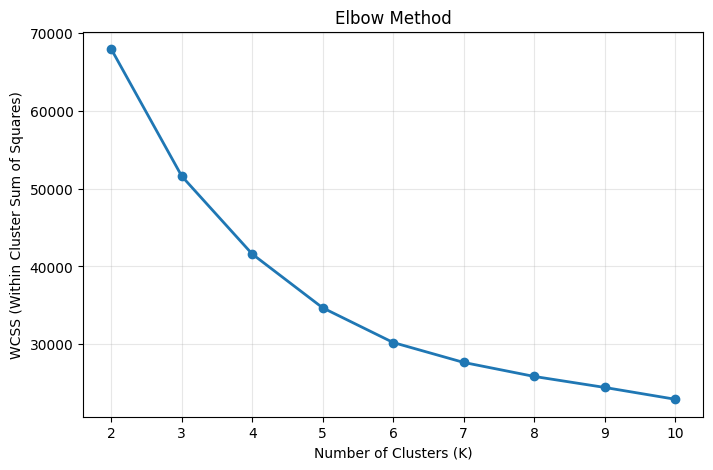

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Within Cluster Sum of Squares)")
plt.title("Elbow Method")

plt.grid(alpha=0.3)

plt.show()

In [19]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    silhouette_scores.append(score)

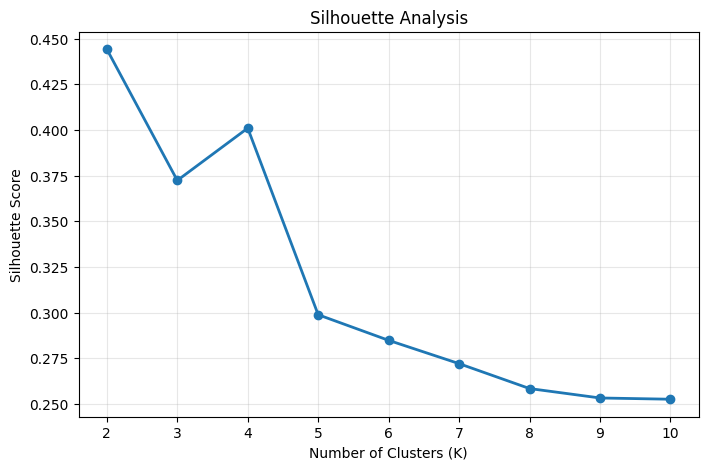

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid(alpha=0.3)

plt.show()

##Based on Elbow Mthod and Silhouette Analysis K is chosen to be 4

In [21]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

In [22]:
df["Cluster"] = clusters

df.head()

,Loyalty Number,Total Flights,Total Distance,Total Points Earned,Total Points Redeemed,Active Months,Avg Flights per Active Month,Redemption Ratio,Avg Distance per Flight,Enrollment Year,Enrollment Month,Loyalty Tenure (Months),Last Flight Date,Months Since Last Flight,Churn,At Risk,Cluster
0,100018,46,81190,81190.0,1513,11.0,4.181818,0.018635,1765.000000,2016,8,28,2018-12-01,0.0,0,0,0
1,100102,51,68918,68918.0,1195,12.0,4.250000,0.017339,1351.333333,2013,3,69,2018-12-01,0.0,0,0,0
2,100140,47,72856,72856.0,593,11.0,4.272727,0.008139,1550.127660,2016,7,29,2018-11-01,1.0,0,0,0
3,100214,22,38236,38236.0,861,7.0,3.142857,0.022518,1738.000000,2015,8,40,2018-12-01,0.0,0,0,1
4,100272,37,54997,54997.0,1007,11.0,3.363636,0.018310,1486.405405,2014,1,59,2018-11-01,1.0,0,0,0


In [23]:
df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,10529
1,3796
2,1619
3,793


In [24]:
cluster_summary = df.groupby("Cluster")[[
    "Total Flights",
    "Total Distance",
    "Total Points Redeemed",
    "Active Months",
    "Avg Flights per Active Month",
    "Avg Distance per Flight",
    "Loyalty Tenure (Months)"
]].mean().round(2)

cluster_summary

,Total Flights,Total Distance,Total Points Redeemed,Active Months,Avg Flights per Active Month,Avg Distance per Flight,Loyalty Tenure (Months)
Cluster,,,,,,,
0,38.69,58078.26,1013.60,10.09,3.84,1501.79,48.23
1,15.18,22517.06,331.63,5.19,2.90,1511.99,15.44
2,0.06,39.20,5.66,1.20,1.53,20.91,40.97
3,55.08,82998.18,454.33,6.36,8.97,1512.38,10.21


In [26]:
cluster_distribution = (
    df["Cluster"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

cluster_distribution

,proportion
Cluster,
0,62.91
1,22.68
2,9.67
3,4.74


## Business Recommendations

### Loyal Frequent Travelers
- Offer VIP rewards and premium loyalty benefits.
- Provide exclusive travel offers and lounge access.

### Growing Customers
- Encourage repeat travel through bonus miles and personalized promotions.
- Increase engagement using targeted marketing campaigns.

### Inactive Members
- Launch reactivation campaigns with welcome-back offers.
- Provide bonus points for completing their first or next journey.

### High-Engagement New Travelers
- Fast-track loyalty upgrades.
- Promote premium memberships and travel packages.

In [27]:
cluster_names = {
    0: "Loyal Frequent Travelers",
    1: "Growing Customers",
    2: "Inactive Members",
    3: "High-Engagement New Travelers"
}

df["Customer Segment"] = df["Cluster"].map(cluster_names)

df.head()

,Loyalty Number,Total Flights,Total Distance,Total Points Earned,Total Points Redeemed,Active Months,Avg Flights per Active Month,Redemption Ratio,Avg Distance per Flight,Enrollment Year,Enrollment Month,Loyalty Tenure (Months),Last Flight Date,Months Since Last Flight,Churn,At Risk,Cluster,Customer Segment
0,100018,46,81190,81190.0,1513,11.0,4.181818,0.018635,1765.000000,2016,8,28,2018-12-01,0.0,0,0,0,Loyal Frequent Travelers
1,100102,51,68918,68918.0,1195,12.0,4.250000,0.017339,1351.333333,2013,3,69,2018-12-01,0.0,0,0,0,Loyal Frequent Travelers
2,100140,47,72856,72856.0,593,11.0,4.272727,0.008139,1550.127660,2016,7,29,2018-11-01,1.0,0,0,0,Loyal Frequent Travelers
3,100214,22,38236,38236.0,861,7.0,3.142857,0.022518,1738.000000,2015,8,40,2018-12-01,0.0,0,0,1,Growing Customers
4,100272,37,54997,54997.0,1007,11.0,3.363636,0.018310,1486.405405,2014,1,59,2018-11-01,1.0,0,0,0,Loyal Frequent Travelers


In [28]:
df.to_csv("customer_segments.csv", index=False)

cluster_summary.to_csv("cluster_summary.csv")

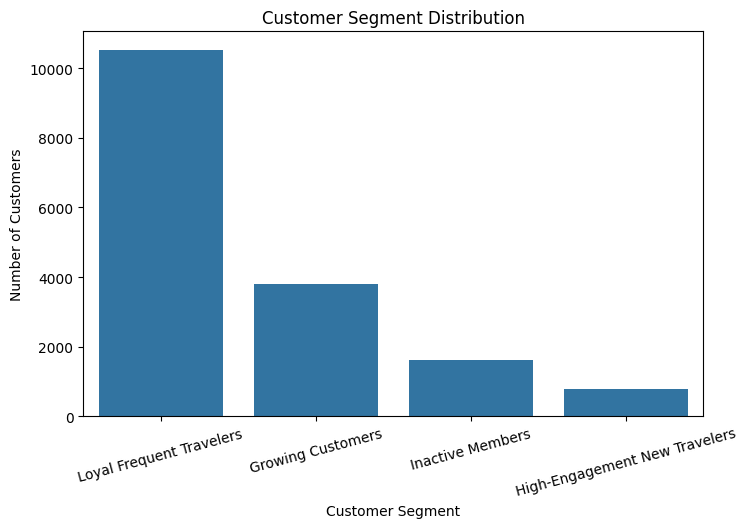

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Customer Segment",
    order=df["Customer Segment"].value_counts().index
)

plt.xticks(rotation=15)
plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

## PCA Visualization

The customer clusters were projected onto two principal components using Principal Component Analysis (PCA).

PCA reduces the dimensionality of the dataset while preserving as much variation as possible. This allows the customer segments identified by K-Means clustering to be visualized in two dimensions.

Although some information is lost during dimensionality reduction, PCA provides an intuitive representation of how well the customer clusters are separated.

In [30]:
from sklearn.decomposition import PCA

In [31]:
pca = PCA(n_components=2, random_state=42)

pca_data = pca.fit_transform(scaled_data)

In [32]:
pca_df = pd.DataFrame({
    "PC1": pca_data[:,0],
    "PC2": pca_data[:,1],
    "Cluster": df["Customer Segment"]
})

pca_df.head()

,PC1,PC2,Cluster
0,2.130680,-0.249590,Loyal Frequent Travelers
1,1.994665,1.233682,Loyal Frequent Travelers
2,1.524288,-0.532594,Loyal Frequent Travelers
3,-0.218032,-0.059703,Growing Customers
4,1.014661,0.910029,Loyal Frequent Travelers


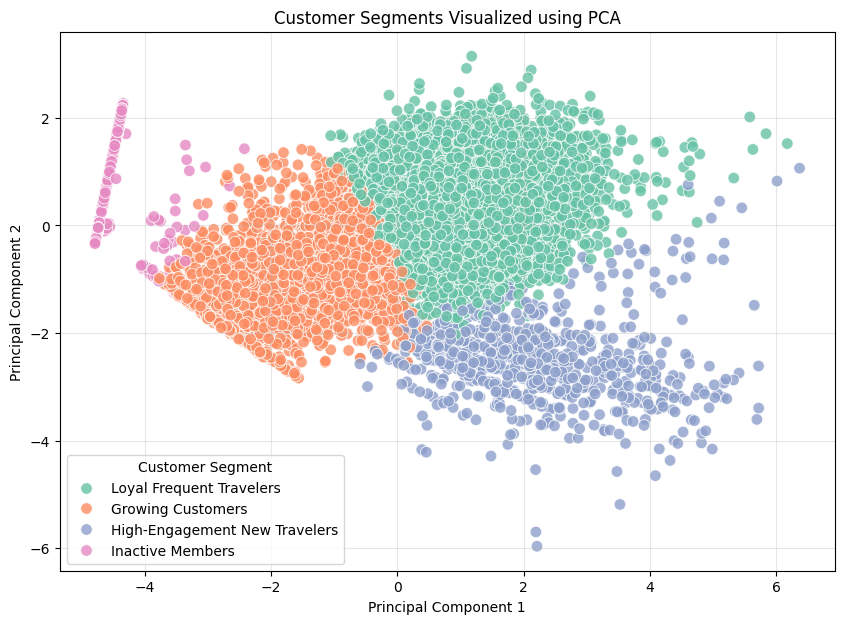

In [33]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=70,
    alpha=0.8
)

plt.title("Customer Segments Visualized using PCA")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Customer Segment")

plt.grid(alpha=0.3)

plt.show()

## PCA Interpretation

The PCA visualization provides a two-dimensional representation of customer segments.

Although some overlap exists between customer groups, the visualization demonstrates that customers with similar behavioral characteristics are grouped together.

This confirms that the K-Means algorithm successfully identified meaningful customer segments that can support targeted marketing and customer relationship strategies.

In [34]:
cluster_summary.to_csv("cluster_summary.csv")
df.to_csv("customer_segments.csv", index=False)

In [35]:
from google.colab import files

files.download("cluster_summary.csv")
files.download("customer_segments.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
plt.savefig(
    "customer_segments_pca.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [37]:
files.download("customer_segments_pca.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>